In [119]:
from cirq_sic import *
import random
import matplotlib.pyplot as plt

In [139]:
def flatten_if_needed(D):
    return D if D.ndim == 3 else D.reshape(-1, D.shape[-1], D.shape[-1])

def renyi_stabilizer_entropy(D, ket, alpha=2, quick=False):
    D = flatten_if_needed(D)
    if len(rho.shape) == 1:
        rho = np.outer(rho, rho.conj())
    d = rho.shape[0]        
    chi = np.array([abs((a.conj().T @ rho).trace())**2 for a in D])/d
    return (1/(1-alpha))*np.log(np.sum(chi**alpha)) - np.log(d)

def max_renyi_stabilizer_entropy(d, alpha=2):
    return (1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d)

def linear_stabilizer_entropy(D, ket):
    D = flatten_if_needed(D)
    d = ket.shape[0]
    chi = np.array([abs(ket.conj() @ O @ ket)**2 for O in D])/d
    return 1 - d*sum(chi**2)

def max_linear_stabilizer_entropy(d):
    D = wh_operators(d)["D"]
    return linear_stabilizer_entropy(D, load_sic_fiducial(d))

def avg_linear_stabilizer_entropy(d, nqubits=False):
    if nqubits:
        return 1 - 4/(d+3)
    if d % 2 != 0:
        return 1 - 3/(d+2)
    return 1 - 3*(d+2)/((d+1)*(d+3))
    
def t_doped_clifford_circuit(qubits, n_layers, rng=None):
    """Return a Circuit with n_layers; each layer is a random Clifford block then a T gate on a random qubit."""
    rng = random.Random(rng)
    qubits = list(qubits)
    circuit = cirq.Circuit()
    for _ in range(n_layers):
        for q in qubits:
            rand_clifford = rng.choice([cirq.H, cirq.S, cirq.X, cirq.Y, cirq.Z])
            circuit.append(rand_clifford(q))
        if len(qubits) >= 2:
            control, target = rng.sample(qubits, 2)
            circuit.append(cirq.CNOT(control, target))
        circuit.append(cirq.T(rng.choice(qubits)))
    return circuit

In [244]:
n = 2
D = wh_operators(2**n)["D"]
qubits = cirq.LineQubit.range(n)

n_runs = 750
max_layers = 30
se_means,se_stds = [], []
def_means, def_stds = [], []
for n_layers in range(1, max_layers+1):
    layer_se = []
    layer_def = []
    for _ in range(n_runs):
        circuit = t_doped_clifford_circuit(qubits, n_layers=n_layers)
        final_ket = cirq.Simulator().simulate(circuit).final_state_vector

        se = linear_stabilizer_entropy(D, final_ket)
        layer_se.append(se)

        R = wh_povm(final_ket)
        P = np.array([[(a@b).trace()/b.trace() for b in R] for a in R]).real
        if np.all(np.linalg.eigvals(P) > 0.001):
            Phi = np.linalg.inv(P)
            deformation = np.linalg.norm(np.eye(P.shape[0])-Phi)
            layer_def.append(deformation)
    se_means.append(np.mean(layer_se))
    se_stds.append(np.std(layer_se))
    def_means.append(np.mean(layer_def))
    def_stds.append(np.std(layer_def))

/Users/heyredhat/miniforge3/envs/cirq_sic/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/heyredhat/miniforge3/envs/cirq_sic/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/heyredhat/miniforge3/envs/cirq_sic/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/heyredhat/miniforge3/envs/cirq_sic/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/heyredhat/miniforge3/envs/cirq_sic/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


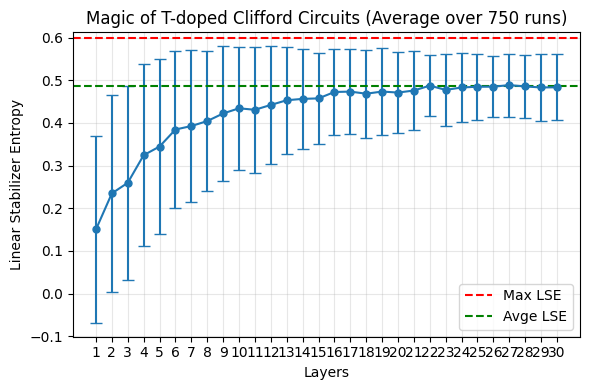

In [246]:
plt.figure(figsize=(6,4))
x = np.arange(1, len(se_means)+1)
plt.errorbar(x, se_means, yerr=se_stds, fmt='-o', capsize=4, lw=1.5, ms=5)
plt.axhline(y=max_linear_stabilizer_entropy(2**n), color='r', linestyle='--', label='Max LSE')
plt.axhline(y=avg_linear_stabilizer_entropy(2**n), color='g', linestyle='--', label='Avge LSE')
plt.xlabel("Layers")
plt.xticks(x)
plt.ylabel("Linear Stabilizer Entropy")
plt.title("Magic of T-doped Clifford Circuits (Average over %d runs)" % n_runs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

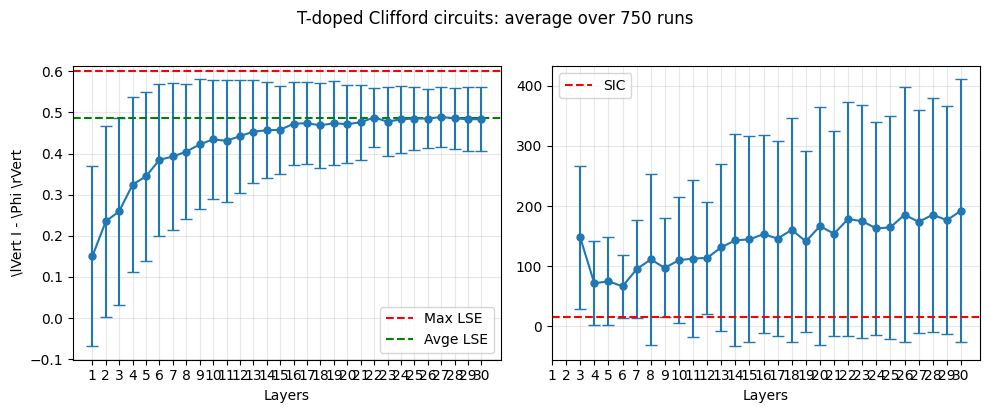

In [247]:

SIC_Phi = np.linalg.inv(SIC_P(2**n))
sic_def = np.linalg.norm(np.eye(SIC_Phi.shape[0])-SIC_Phi)
x = np.arange(1, len(se_means) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.errorbar(x, se_means, yerr=se_stds, fmt='-o', capsize=4, lw=1.5, ms=5)
ax1.axhline(y=max_linear_stabilizer_entropy(2**n), color='r', linestyle='--', label='Max LSE')
ax1.axhline(y=avg_linear_stabilizer_entropy(2**n), color='g', linestyle='--', label='Avge LSE')
ax1.set_xlabel("Layers")
ax1.set_ylabel("Linear Stabilizer Entropy")
ax1.set_xticks(x)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.errorbar(x, def_means, yerr=def_stds, fmt='-o', capsize=4, lw=1.5, ms=5)
ax2.axhline(y=sic_def, color='r', linestyle='--', label='SIC')
ax2.set_xlabel("Layers")
ax1.set_ylabel(r"\lVert I - \Phi \rVert")
ax2.set_xticks(x)
ax2.grid(True, alpha=0.3)
ax2.legend()

fig.suptitle(f"T-doped Clifford circuits: average over {n_runs} runs", y=1.02)
plt.tight_layout()
plt.show()
